# imports

In [14]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import mlflow
import matplotlib.pyplot as plt

# config

In [7]:
ASSET = "BTC"
INTERVAL = "1h"

# load data 

In [8]:
train_df = pd.read_parquet('../../../data/processed/train_btc_1h.parquet')
test_df = pd.read_parquet('../../../data/processed/test_btc_1h.parquet')

# targets nd tests

In [9]:
y_train = train_df.pop('target_direction')
X_train = train_df.drop(columns=['target_1h'], errors='ignore')
y_test = test_df.pop('target_direction')
X_test = test_df.drop(columns=['target_1h'], errors='ignore')

# mlflow

In [10]:
mlflow.set_tracking_uri("http://localhost:5000")
experiment_name = f"{ASSET}_{INTERVAL}_XGBoost"
mlflow.set_experiment(experiment_name)
mlflow.xgboost.autolog()

2026/05/11 15:48:33 INFO mlflow.tracking.fluent: Experiment with name 'BTC_1h_XGBoost' does not exist. Creating a new experiment.
2026/05/11 15:48:33 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 2.1.0 <= xgboost, but the installed version is 2.0.3. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.


# run with mlflow

In [11]:
with mlflow.start_run(run_name="XGBoost_1strun"):
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        eval_metric='logloss',
        random_state=42
    )
    
    print("training...")
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    y_pred = xgb_model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    print(f"\n done ")
    print(f" Accuracy: {test_acc:.4f}")
    print(" Report:")
    print(classification_report(y_test, y_pred))

training...


2026/05/11 15:49:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 done 
 Accuracy: 0.5281
 Report:
              precision    recall  f1-score   support

           0       0.53      0.51      0.52      5331
           1       0.53      0.55      0.54      5373

    accuracy                           0.53     10704
   macro avg       0.53      0.53      0.53     10704
weighted avg       0.53      0.53      0.53     10704

🏃 View run XGBoost_1strun at: http://localhost:5000/#/experiments/14/runs/3f5da66fb47547f8b53fc608a6c13e32
🧪 View experiment at: http://localhost:5000/#/experiments/14


# before tuning up getting important features 

In [12]:
importances = xgb_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)[::-1]
print("15 important features:")
for i in range(15):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

15 important features:
1. sma_7_dist: 0.1314
2. close_position: 0.0539
3. ema_26_dist: 0.0395
4. vwap_dist: 0.0392
5. ema_12_dist: 0.0391
6. sma_30_dist: 0.0381
7. ema_50_dist: 0.0377
8. returns_1p: 0.0370
9. rsi_14: 0.0366
10. macd_pct: 0.0364
11. roc_10: 0.0363
12. returns_5p: 0.0362
13. volume_ratio: 0.0357
14. macd_hist_pct: 0.0355
15. sma_100_dist: 0.0351


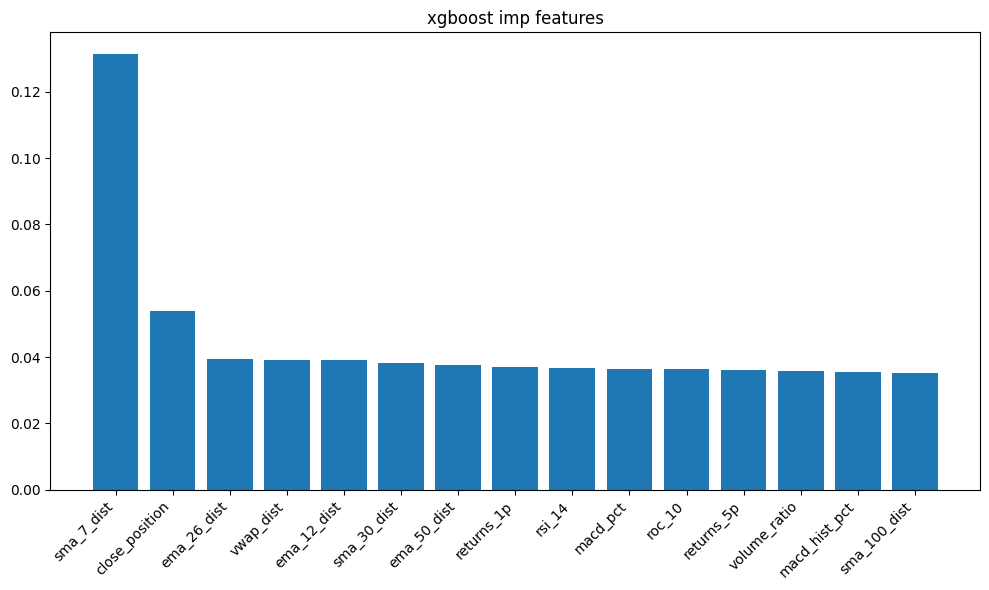

In [15]:
plt.figure(figsize=(10, 6))
plt.title("xgboost imp features")
plt.bar(range(15), importances[indices][:15], align="center")
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()